<a href="https://colab.research.google.com/github/ioan-vlad-pantiru/cvdlp/blob/main/Computer_Vision_and_Deep_Learning_Laboratory_2_pytorch%5Bstudents%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 2

The topic for today's laboratory is simple image classification. It's the single laboratory in which we will got back to the basics and implement things from scratch. You will learn about loss functions, evaluation metrics and experiment management.
I suggest that you don't work in notebooks for this lab, but create a python project.



## Warm-up. numpy exercise

Let's start by implementing the softmax function. This function takes as input an array of *N* arbitrary numbers and normalizes the array such that the output is a probability distribution.


\begin{equation}
softmax(x)_i = \frac{e^{x_i}}{\sum_{j = 0}^{j = N} e^{x_j}}
\end{equation}


**Have a short discussion about softmax numerical stability.** You can also check this [post](https://ogunlao.github.io/2020/04/26/you_dont_really_know_softmax.html).


In [121]:
import numpy as np
import torch

def softmax(x, T=1.0):
    x = np.asarray(x, dtype=float)
    x_shifted = (x - x.max()) / T
    e_x = np.exp(x_shifted)
    return e_x / e_x.sum()

# validate softmax
arr = np.asarray([2, 4, 10, 100, 2.0])
assert (np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr)))
arr = np.asarray([0.0, 0, 0, 1, 0])
assert (np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr)))
arr = np.asarray([-750.0, 23, 9, 10, 230])
assert (np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr)))
arr = np.ones((4, ))
assert (np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr)))
arr = np.zeros((4, ))
assert (np.allclose(torch.nn.functional.softmax(torch.from_numpy(arr), dim=0).numpy(), softmax(arr)))
print("All softmax assertions passed.")

All softmax assertions passed.


*Softmax temperature* is a concept that we'll be using later in this course.
The *softmax temperature* is a hyper-parameter (positive number) which scales the input of the softmax function to modify the output probabilities.


\begin{equation}
s(x, T)_i = \frac{e^{x_i/T}}{\sum_{j = 0}^{j = N} e^{x_j/T}}
\end{equation}

Now modify your implementation of the softmax function such that it also takes as input the softmax temperature (a positive floating point number). If this parameter is not specified, it should default to 1.


Now let's visualise what is the effect of the softmax temperature.
Given the input vector *x = [100, 2, -150, 75, 99, 3]* , plot the original vector and the softmax with temperatures $ T \in \{0.25, 0.75, 1, 1.5, 2, 5, 10, 20, 30\} $.

You can use a bar plot for this. The title for each plot should be the value of the softmax temperature. Also, make sure that for all the plots the range of the *y* axis is set to (0, 1).



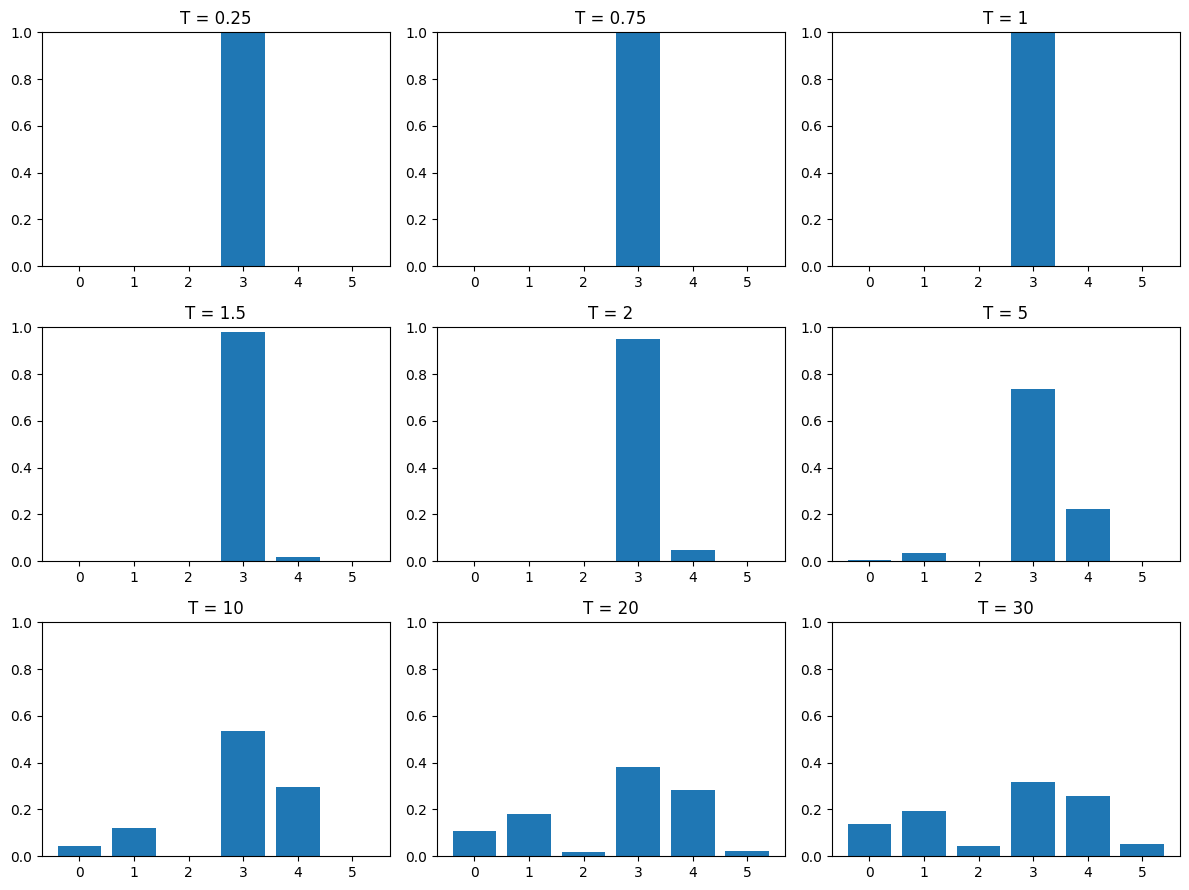

In [122]:
import matplotlib.pyplot as plt

x = np.asarray([20, 30, -15, 45, 39, -10])
T = [0.25, 0.75, 1, 1.5, 2, 5, 10, 20, 30]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for idx, t in enumerate(T):
    ax = axes[idx // 3][idx % 3]
    ax.bar(range(len(x)), softmax(x, T=t))
    ax.set_ylim(0, 1)
    ax.set_title(f'T = {t}')
plt.tight_layout()
plt.show()



Analyse the plots and answer the following questions:
* What happens when we use a large number for the softmax temperature?
* What happens when we use a small number (i.e. less than 1) for the softmax temperature?
* In the context of image classification, the predicted class is determined by taking the *argmax* of the softmax function. Does the softmax temperature change in any way this prediction?

## Dataset

We'll be using CIFAR-10 dataset.
The dataset comprises 60000 colour images with a resolution of $32 \times 32$, separated into 10 classes, with 6000 images per class. It is already split into train-test subsets, with 50000 training images and 10000 test images.

You can download the data from this [link](https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz).

In [123]:
![ -d cifar-10-batches-py ] || (wget -q https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz && tar -xf cifar-10-python.tar.gz && rm cifar-10-python.tar.gz)

1.  **Write a script *cifar10.py* in which will write the function load_cifar10, which load the data from the archive you just downloaded.**

The images of this dataset are are stored in a numpy array, one image per row, in the following order:

"_The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image._"

Your task here is just to manipulate this array, such that each image has the shape (32, 32, 3) and uses RGB ordering.

2. **Using matplotlib, write a function that visualizes some of the images from the CIFAR-10 dataset.**

/Users/pantiruvlad/Documents/Facultate/3rd_year/cvdlp/lab2/cifar10.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='bytes')


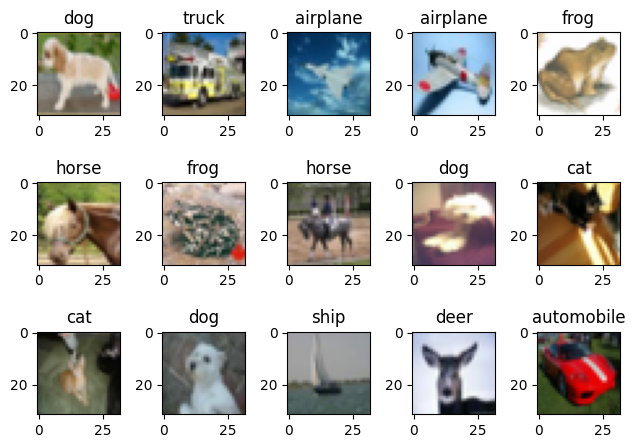

In [124]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from lab2 import cifar10

cifar_root_dir = 'cifar-10-batches-py'
_, _, X_test, y_test = cifar10.load_cifar10(cifar_root_dir)
indices = np.random.choice(len(X_test), 15)

display_images, display_labels = X_test[indices], y_test[indices]
for idx, (img, label) in enumerate(zip(display_images, display_labels)):
    plt.subplot(3, 5, idx + 1)
    plt.imshow(img)
    plt.title(cifar10.LABELS[label])
    plt.tight_layout()
plt.show()

# Image classification using a linear classifier in pytorch




Image classification refers to the problem of automatically assigning a label (a class) to an image $X_i$. As classification is a supervised learning problem, each image is assigned a ground truth label $y_i \in \{1, 2, ..., C\}$.


Today you will implement and train the simplest possible artificial neural network using pytorch.
A linear classifier uses a function $f$ to map an input image $X_i \in R^{H\times W\times 3}$ into a vector of C class scores  $\hat y_i \in R^C$:


\begin{equation}
f(X_i) = X_i \cdot W + b
\end{equation}


The learnable parameters of the classifier are the weight matrix $W$ and the bias vector $b$. Using the bias trick the bias term can be included in the weight matrix.


During the training process, the values of the weight matrix are learned by minimizing a loss function (that penalizes the discrepancy between the predicted and the ground truth label).


In your implementation, use the bias trick and add the bias value in the weight matrix and a 1 in the training and test data:


```
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
```


## Implementation


[Pytorch](https://pytorch.org/) is a powerful machine learning framework widely used for computer vision and natural language processing applications that we'll be using this semester.
[Tensors](https://pytorch.org/docs/stable/tensors.html) are the main data abstraction from pytorch; similar to numpy arrays, they represent multi-dimensional arrays of a single data type.
You can think of a tensor as consisting of some data, and then some metadata describing the size of the tensor, the type of the elements it contains (dtype) and what device the tensor lives on (CPU memory? CUDA memory?).


It is quite easy to transform tensors to and from numpy arrays:
- _from_numpy()_ function allows you to create a pytorch tensor from a numpy array.
- _numpy()_ functions allows you to convert a tensor to a numpy() array.


Also, you will use the function _item()_ to convert a tensor to a scalar python value.


Another important feature of pytorch is the _autograd_ module that provides classes and functions for automatic differentiation of arbitrary scalar valued functions. This module is really easy to use, you only need to declare Tensor's for which gradients should be computed by setting the _requires_grad_ attribute of a tensor to True.
As you know, most machine learning models are trained using the gradient descent algorithm. This is a first-order iterative optimization algorithm used to find the minimum of a differentiable function: the main idea is to take repeated steps in the opposite direction of the gradient  of the function at the current point (i.e. in the direction of steepest descent).






### Softmax classification


We'll follow an object oriented approach to solve this problem.
All the code related to the softmax classifier will be implemented in a class *SoftmaxClassifier* (defined in the script _softmax.py_).


The _SoftmaxClassifier_ class contains in the  attribute _self.W_ the weight matrix that will be learned during the training process.  


The class should have the following methods:


| Method                               | Description |
| ----------- | ----------- |
| initialize()      | This function randomly initializes the weights of the linear classifier.    |
| fit(X_train, y_train, **kwargs)      | This function will learn the weights of the model based on the training data samples (X_train) and their corresponding ground truth (y_train)       |
|  predict(X)                | This function will return the classifier's prediction (the predicted class) for the data passed as parameter.        |
|  predict_proba(X)                | This function will return the classifier's predictions for the data passed as parameters.        |
|  save(path)   | This function will dump the weights of the classifier in the path specified as parameter.        |
|  load(load)   | This function will load the classifier's weights from the path specified as parameter      |


Feel free to add any additional helper methods if needed.


#### Initialization and persistence
* The constructor of this class takes as input the flattened size of the input image and the number of output classes, sets the corresponding class variables and calls the _init()_ method.
* fill in the _initialize()_ method. You figure out the shape of the weight matrix based on the input shape and the number of classes. Initialize the weight matrix with small random variables.
__Use the bias trick__!
* fill in the _save_ and _load_ functions. In these functions you should just dump and restore, respectively, the weight matrix to/from the specified file.


#### Inference - the _predict_ and _predict\_proba_ methods


The inference is quite simple. You just need to compute the dot product between the input and the weight matrix.
You will implement two inference methods:
* _predict_ - this will just return the predicted class label. So you just need to compute the dot product and take the argmax of the result.
* _predict\_proba_ - this will return the class probabilities. So after computing the dot product, you also need to apply the softmax function on the result to normalize it to a probability distribution.


If you implement this correctly, the _SoftmaxClassifier_ can be used to make predictions, but of course they are not very accurate as we haven't trained the model yet.



#### Training - the _fit_ method

The training process is implemented in the function _fit_ : here we are interested in finding the values for the weight matrix such that the classifier gives accurate predictions.

The loss function for the softmax classifier is defined as:

\begin{equation}
L_i = - \sum_{i=1}^{C} log(\hat{y\_pred}_i)\cdot y_i.
\end{equation}

, where $\hat{y_p}_i$ are the probabilities returned by the classifier for the ith sample and $y_i$ is the corresponding ground truth (as one hot encoding).

So in the ``cross_entropy`` function you just take the negative of the logarithm of the predicted probability for the ground truth class.

In the case of the softmax classifier $\hat{y\_pred}_i$ is always a value in the interval [0, 1] (we use the softmax function to normalize the logits into a probability distribution).
When the probability of the ground truth class is small (i.e. close to 0), the loss will be very high (theoretically, infinite) [log(0) = -inf]. On the other hand, when the probability of the correct class will be high (i.e. close to 1), then the loss will be close to 0 [log(1) = 0].

For numerical staibility instead of using softmax, we'll use the log softmax.

In the function `log_softmax` implement the following:
\begin{equation}
log\_softmax(x_i) =  log(\frac{e^{x_i}}{\sum_{j}e^{x_j}}) = x_i - log(\sum_j e^x_j)
\end{equation}

Then, in the ``fit`` method:
\begin{equation}
y\_pred_i = f(x_i)
\end{equation}

\begin{equation}
\hat{y\_pred_i} =  log\_softmax(y\_pred_i)
\end{equation},

and take the cross entropy loss between $\hat{y\_pred_i}$ and $y_i$ to compute the data loss.

For this we need two steps:
1. we need to define a loss function that quantifies our
how well is the classifier doing on the training data. The loss function that we will use is the **cross entropy loss**.
Remember from the lecture that, in order to avoid overfitting, a regularization term is added to the loss function.
You will implement the $L_2$ regularization, in which you also add the  sum of squares of all of the feature weights to the loss.


2. we need an algorithm to efficiently find the
parameters that minimize the loss function.

Pytorch provides a powerful feature, _autograd_: it allows for the rapid and easy computation of multiple partial derivatives (also referred to as gradients) over a complex computation. This operation is central to backpropagation-based neural network learning.

You can follow [this](https://pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html) post for more details about how autograd works.
We'll cover autograd in more detail in the next labs.

For now, we'll be using it to make your life easier when implementing gradient descent to train the softmax classifier. In gradient descent, the idea is to take repeated steps in the opposite direction of the gradient of the loss function at the current point. The backpropagation algorithm works by computing the gradient of the loss function with respect to each weight by the chain rule, computing the gradient one layer at a time, and iterating backward from the last layer to avoid redundant calculations of intermediate terms in the chain rule.

To signal autograd that it should collect the gradients of a tensor, you need to pass the parameter _requires_grad=True_ when creating it or call the method _requires_grad_()_ on a tensor.

To __start the backpropagation__ with autograd, you just need to call the _backward()_ function on the loss tensor (a scalar).  
Autograd calculates and stores the gradients for each model parameter in the tensors' _grad_ field.

Let's see how a custom training loop looks in pytorch:

```python
lr = 0.05  # learning rate: what is the size of the step that we will take in the opposite direction of the gradient
epochs = 32  # how many epochs (passes through the traing data) we'll peform
bs = 32 # batch size:  we'll update the parameters after seeing several examples (a batch of data)

for epoch in range(epochs):    
    for ii in range((X_train.shape[0] - 1) // bs + 1):  # in batches of size bs
        start_idx = ii * bs  # we are ii batches in, each of size bs
        end_idx = start_idx + bs  # get bs examples

        # get the training training examples xb, and their coresponding annotations
        xb = X_train[start_idx:end_idx]
        yb = y_train[start_idx:end_idx]

        # apply the model on the training examples
        pred = predict_proba(xb)

        # compute the loss function
        loss = cross_entropy_loss(pred, yb)

        # start backpropagation: calculate the gradients with a backwards pass
        loss.backward()

        # update the parameters
        with torch.no_grad():  # we don't want to track gradients
            # take a step in the negative direction of the gradient, the learning rate defines the step size
            weights -= weights.grad * lr

            # ATTENTION: you need to explictly set the gradients to 0 (let pytorch know that you are done with them).
            weights.grad.zero_()
            
``





## Putting it all together


By now you have implemented all the blocks needed to train a softmax classifier. Now it is time to train the classifier using different hyperparameters.

Try different values for the hyper-parameters of the classifier (the learning rate $\lambda$ and the regularization strength $\rho$).


## Visualizing learned weights as class templates

After training the linear classifier, the weight matrix `W` has shape `(10, 3072)`,
one row per CIFAR-10 class. Since each input image is flattened into a vector,
each row of `W` can be reshaped back into an image of size $32 \times 32 \times 3$.

For a given class $c$, the classifier computes the score  
$s_c = w_c^T x + b_c$.  
This score is large when the input image $x$ is similar to the weight vector
$w_c$ in terms of correlation. During training, the model learns each `w_c` so
that images of class $c$ align well with it, while images from other classes do
not.

Because of this, each row of the weight matrix can be interpreted as a rough
**template** for its class. Visualizing these weights usually does not produce
clean images, but you can often recognize coarse structure such as dominant
colors or simple shapes. This gives an intuitive view of what a linear classifier
has learned about each class in the CIFAR-10 dataset.


In [125]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from lab2 import cifar10 as cf10
from lab2.softmax import SoftmaxClassifier

# Load and pre-process data
_X_train, _y_train, _X_test, _y_test = cf10.load_cifar10('cifar-10-batches-py')
_X_train = _X_train.reshape(_X_train.shape[0], -1).astype(np.float32)
_X_test  = _X_test.reshape(_X_test.shape[0],  -1).astype(np.float32)
_mean = _X_train.mean(axis=0)
_X_train -= _mean
_X_test  -= _mean

clf = SoftmaxClassifier(input_size=_X_train.shape[1], num_classes=10)
clf.fit(_X_train, _y_train, lr=0.01, reg=1e-4, epochs=30, batch_size=256)

import torch
_tr_acc = (clf.predict(_X_train) == torch.tensor(_y_train)).float().mean().item()
_te_acc = (clf.predict(_X_test)  == torch.tensor(_y_test)).float().mean().item()
print(f'SoftmaxClassifier — train acc: {_tr_acc:.4f}  test acc: {_te_acc:.4f}')

clf.save('softmax_weights.pt')
print('Weights saved to softmax_weights.pt')

SoftmaxClassifier — train acc: 0.2512  test acc: 0.2210
Weights saved to softmax_weights.pt


## Refactoring using torch components


Luckily pytorch provides implementation for most of the layers used in modern machine learning, as well as loss functions, metrics, and optimization algorithms.


To define a model, you must extend the torch.nn.Module class which is the base class for all the neural network modules. In the constructor, you define the layers (and their properties) that comprise your module. The line


Another important function that you need to override is the forward() function in which you specify computation performed at every call (i.e. how are layers chained and how does the data flow over the computational graph). In other words, this defines the forward pass through your model.



In [126]:
import torch
from torch import nn

class Cifar10Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3072, 10)

    def forward(self, x):
        return self.linear(x)

the `nn.Linear` layer is a "child"
of the `Cifar10Classifier`,
and the weight matrix is abstracted (you don't have direct access to it).


In [127]:
model = Cifar10Classifier()
print(*list(model.children()))

Linear(in_features=3072, out_features=10, bias=True)


But you can still access the parameters of the model (the bias trick is not used in this case):

In [128]:
print(*list(model.parameters()), sep="\n")

Parameter containing:
tensor([[-0.0095, -0.0115, -0.0030,  ...,  0.0002,  0.0048,  0.0139],
        [-0.0017,  0.0025, -0.0097,  ...,  0.0011,  0.0110, -0.0109],
        [-0.0100, -0.0102,  0.0179,  ...,  0.0084, -0.0011, -0.0149],
        ...,
        [ 0.0024,  0.0112,  0.0090,  ..., -0.0178,  0.0117,  0.0090],
        [-0.0168, -0.0167, -0.0178,  ..., -0.0159, -0.0083,  0.0179],
        [-0.0143, -0.0115, -0.0149,  ..., -0.0101,  0.0014,  0.0033]],
       requires_grad=True)
Parameter containing:
tensor([-0.0151, -0.0161, -0.0038, -0.0116,  0.0029, -0.0100, -0.0029, -0.0017,
         0.0004,  0.0128], requires_grad=True)


Torch also provides several loss functions that you can use in the `torch.nn.functional` model. Let's drop the log_softmax and cross_entropy function that you wrote and use `torch.nn.functional.cross_entropy`[function](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html).
Pay attention: you don't need to apply the log-softmax on the prediction of the model as the function operates directly on  unnormalized logits.

In [129]:
loss_func = torch.nn.functional.cross_entropy

The optimization process (applying gradients to find the parameters and resetting those gradients to zero) can be handled more elegantly using predefined pytorch classes and operations.


You just need a subclass of the torch.optim.Optimizer, and it will automatically update the parameters of our model. In this example, we'll be using the Adam optimizer (which will be covered in detail in the lectures).


In [130]:
from torch import optim

def configure_optimizer(model: nn.Module) -> optim.Optimizer:
    return optim.Adam(model.parameters(), lr=3e-4)


Let's reload the data:

In [131]:
from lab2 import cifar10
cifar_root_dir = 'cifar-10-batches-py'

# load cifar10 dataset
X_train, y_train, X_test, y_test = cifar10.load_ciaf10(cifar_root_dir)

# convert the training and test data to floating point
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Reshape the training data such that we have one image per row
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

# pre-processing: subtract mean image and divide by std
mean_image = np.mean(X_train, axis=0)
std_image = np.std(X_train, axis=0) + 1e-8
X_train = (X_train - mean_image) / std_image
X_test = (X_test - mean_image) / std_image

# convert everything to tensors
X_train, y_train, X_test, y_test = map(
    torch.tensor, (X_train, y_train, X_test, y_test)
)

X_train = X_train.float()
X_test = X_test.float()

Now, the training loop will be much simpler:

In [132]:
import tqdm
model = Cifar10Classifier()
opt = configure_optimizer(model)


print("before training:", loss_func(model(X_test), y_test), sep="\n\t")
epochs = 50
bs = 64
num_train = X_train.shape[0]

epoch_iter = tqdm.tqdm(range(epochs), desc="Epochs")

for epoch in epoch_iter:
    for ii in range((num_train - 1) // bs + 1):
        start_idx = ii * bs
        end_idx = start_idx + bs
        xb = X_train[start_idx:end_idx]
        yb = y_train[start_idx:end_idx]
        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()
        opt.step()
        opt.zero_grad()

with torch.no_grad():
    y_train_pred = model(X_train).argmax(dim=1)
    train_acc = (y_train_pred == y_train).float().mean()
    y_val_pred = model(X_test).argmax(dim=1)
    test_acc = (y_val_pred == y_test).float().mean()

print('Train acc ', train_acc.item(), ' test acc ', test_acc.item())
print("after training:", loss_func(model(X_test), y_test), sep="\n\t")

before training:
	tensor(2.3800, grad_fn=<NllLossBackward0>)


Epochs: 100%|██████████| 50/50 [00:14<00:00,  3.53it/s]

Train acc  0.4541400074958801  test acc  0.384799987077713
after training:
	tensor(1.8046, grad_fn=<NllLossBackward0>)


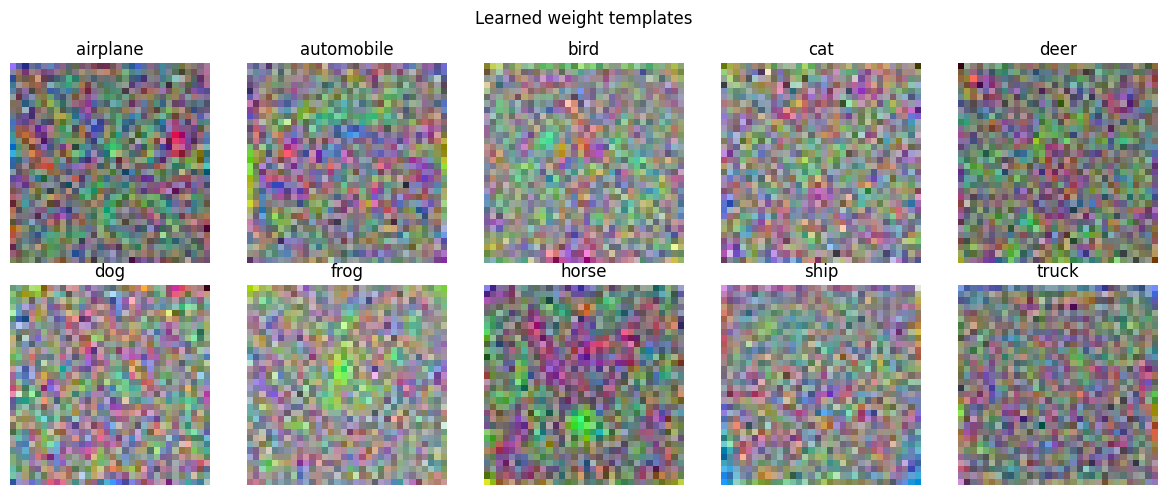

In [133]:
# Visualize learned weight templates
weights = model.linear.weight.detach().numpy()  # (10, 3072)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, w, label in zip(axes.flat, weights, cifar10.LABELS):
    img = w.reshape(32, 32, 3)
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')
plt.suptitle('Learned weight templates')
plt.tight_layout()
plt.show()

## Classifier evaluation

After the training process, you want to evaluate the model on the test set, such that you can get an idea on how well your model will perform on unseen data.
Ideally the classes in the test set should be balanced (i.e. you should have the same number of samples for each one of the classes).

### Confusion matrix and classification metrics

The confusion matrix can be considered the foundation stone for evaluating a classifier. As the name states, it's a simple way of visualising whether/how the model is confusing the classes.

Each row of the confusion matrix represents the instances of the ground truth class, while each column represents the instances of the predicted class.

<img src="https://2.bp.blogspot.com/-EvSXDotTOwc/XMfeOGZ-CVI/AAAAAAAAEiE/oePFfvhfOQM11dgRn9FkPxlegCXbgOF4QCLcBGAs/s1600/confusionMatrxiUpdated.jpg"/>

Based on the confusion matrix, you can compute different classification metrics:
* *accuracy*: this is simply the ratio between the correctly classified samples (either positive or negative) and the total number of samples;
* _precisi**on**_ : this metric measures the ability of the classifier to capture **only** relevant samples;
* _rec**all**_ : this metric measures the ability of the classifier to spot **all** positive samples.

As you may have noticed, it is not possible to maximize precision and recall at the same time, as one comes at the cost of another.
Therefore, the $F_1$ score -- the harmonic mean between precision and recall -- was defined to combine these two metrics into a single numerical value.

\begin{equation}
F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}
\end{equation}

Write the code for computing the accuracy, precision, recall and f1-score of your classifier.

One challenge when implementing these metrics is that you are not allowed to use any repetitive loops (only numpy vectorization).

Of course, pytorch provides functions for all these metrics, but for didactical puropose and to gain a deeper understanding of nd-arrays and tenors you should implement them from scratch.



In [134]:
def confusion_matrix(y_true, y_pred, num_classes=10):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_oh = (y_true[:, None] == np.arange(num_classes)[None, :])   # (N, C)
    pred_oh = (y_pred[:, None] == np.arange(num_classes)[None, :])   # (N, C)
    return true_oh.T @ pred_oh                                         # (C, C)


def compute_metrics(y_true, y_pred, num_classes=10):
    C = confusion_matrix(y_true, y_pred, num_classes).astype(float)
    tp = np.diag(C)
    fp = C.sum(axis=0) - tp
    fn = C.sum(axis=1) - tp

    accuracy  = tp.sum() / len(y_true)
    precision = (tp / (tp + fp + 1e-8)).mean()
    recall    = (tp / (tp + fn + 1e-8)).mean()
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    return accuracy, precision, recall, f1


with torch.no_grad():
    y_pred_np = model(X_test).argmax(dim=1).numpy()
    y_true_np = y_test.numpy()

acc, prec, rec, f1 = compute_metrics(y_true_np, y_pred_np)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.0010
Precision: 0.1000
Recall:    0.1000
F1 Score:  0.1000


## Experiment management and reproducibility

When training deep learning models, it is very easy to run *many* experiments:
changing the learning rate, the model architecture, the regularization strength,
the data preprocessing, or even just the random seed. After a few runs, it becomes
hard to answer simple questions such as:

- Which experiment performed best?
- What hyperparameters were used for that run?
- Did the model improve on the training set but not on the test set?

Experiment management is the practice of systematically **recording what you did
and what happened**, so that experiments can be compared in a meaningful way.
We will do this a lot this semester.

## Train logs vs test logs

During training, you will usually track two different kinds of quantities:

- **Training logs**: computed on the training set while the model is being optimized.
  Typical examples are training loss, training accuracy and so on.

- **Test (or validation) logs**: computed on a separate dataset *without* updating
  the model parameters. Typical examples are test loss, test accuracy and so on.

These two sets of logs serve **different purposes**:
- Training metrics tell us whether the optimization is working.
- Test metrics tell us how well the model generalizes to unseen data.

A common situation is: training loss keeps decreasing, training accuracy keeps increasing, test accuracy stops improving or starts decreasing.

This behavior is a strong indicator of **overfitting**.



## Why logging matters

If metrics are only printed to the terminal, they are easy to lose, hard to compare across runs, impossible to visualize after training has finished.

By logging losses and metrics over time, we can:
- visualize learning curves,
- compare multiple experiments side by side,
- understand the effect of hyperparameters and model choices.

To achieve this we'll use wandb.

## Weights & Biases (wandb)

Weights & Biases (wandb) is a tool that helps with experiment management.
At a minimum, it allows you to group metrics by experiment (called a *run*), log training and test metrics over time, attach hyperparameters to each run.

A typical usage pattern is:
1. Initialize a run and specify the experiment configuration (learning rate, model, etc.).
2. Log **training metrics** during optimization (e.g. `train/loss`, `train/accuracy`).
3. Log **test metrics** during evaluation (e.g. `test/loss`, `test/accuracy`).

By consistently naming metrics (for example using prefixes like `train/` and `test/`),
wandb automatically organizes them into clear and comparable plots.



## Putting it all together: experiment management in practice

Let’s now put everything we learned into action.

In this section, you will use **experiment management** to systematically explore
design choices for a simple image classification model. The goal is not only to
train a model, but to **compare experiments in a structured and reproducible way**.

You will use the **PyTorch version of the linear classifier** introduced earlier.


### Part 1 - Hyperparameter exploration

Train the linear classifier using **at least three variants** of:

- learning rate
- weight decay (L2 regularization)

For each experiment log **training loss** and **training accuracy**
- log **test loss** and **test accuracy**, store the hyperparameters in the experiment configuration



### Part 2 - Comparing loss functions


In this part, you will study how the choice of loss function affects training
and performance in a classification problem.

Train the same linear classifier multiple times, changing **only the loss
function**, while keeping the rest of the setup (model, optimizer, data split)
as consistent as possible.

- First, use **RMSE (root mean squared error)** as the training loss. This loss is
commonly used for regression, not for classification. Even though it is not
appropriate in practice, train the model anyway and observe the training
dynamics and final accuracy. Think about how RMSE treats class predictions and
why this leads to poor behavior for multiclass classification.

- Next, train the model using **cross-entropy loss**. This is the standard loss for
multiclass classification and serves as the reference point for your
experiments. Compare its convergence speed, stability, and final test accuracy
with the RMSE-based model.

- Finally, train the model using **hinge loss**, a margin-based loss that is often associated with linear classifiers. You should implement the loss function yourself. For a single training example with score vector $$s \in \mathbb{R}^C$$ and ground truth label \(y\), the multiclass hinge loss is defined as:
 $$
\mathcal{L}_{\text{hinge}}(s, y) = \sum_{j \ne y} \max\left(0,\; s_j - s_y + \Delta \right)
$$ , where: $s_y$ is the score of the correct class, $s_j$ is the score of an incorrect class, $\Delta > 0$ is a margin hyperparameter (typically $\Delta = 1$). The loss encourages the score of the correct class to be larger than the scores
of all other classes by at least the margin $\Delta$.



### Part 3 - Label smoothing

Label smoothing is a regularization technique for classification.

Instead of training with *hard* one-hot labels, we slightly soften the target
distribution. For a classification problem with \(C\) classes and smoothing
parameter $\varepsilon$, the correct class is assigned probability \(1 - \epsilon\) and the remaining probability $\varepsilon$ is distributed uniformly over  the other classes

For example, with \(C = 10\) and $\varepsilon = 0.1$ the correct class will have a probability of $0.9$ and each incorrect class will have a probability of $0.1/9$.

Label smoothing discourages over-confident predictions and it acts as a form of regularization so it can improve generalization.

Your task is to implement label smoothing **yourself** (do not use a built-in helper) retrain the linear classifier with cross-entropy + label smoothing compare the results with standard cross-entropy.



### Part 4 - Analysis and comparison
Use wandb to track all experiments. Each run should clearly record the loss
function being used, together with the learning rate and weight decay. Log
training and test loss and accuracy throughout training so that they can be
visualized over time.

After running all experiments, create a table in wandb that summarizes the
results. The table should include the loss function, learning rate, weight
decay, final training accuracy, and final test accuracy for each run. Use this
table and the logged curves to comment on how the different losses behave and
which ones are most suitable for this task.

The goal of this exercise is not to find the “best” number,
but to practice **systematic experimentation and analysis**.


#Conclusion

In this lab, we went back to the basics, you learned how how to train a simple image classifier from scratch and analyze it in
a systematic way. You implemented and compared different loss functions, explored
the effect of learning rate and regularization, used experiment management to keep
track of your runs, and did some simple visualization of the model weights (we'll continue with these in the next lab).

You won't be computing derivatives by hand nor writing low-level functions in your carrer, but these skills are important because real deep learning work is not just about
writing code that runs, but about designing controlled experiments, interpreting
results, and understanding model behavior. As Andrew Ng says, it's a **very** iterative process.

The same principles you used here
apply directly to larger models and more complex architectures you will encounter
later in the course.

In [ ]:
import logging
import wandb
from torch import optim
import torch.nn.functional as F

logging.getLogger("wandb").setLevel(logging.ERROR)


# ── helpers ───────────────────────────────────────────────────────────────────

def accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()


def hinge_loss(scores, labels, delta=1.0):
    N = scores.shape[0]
    correct = scores[torch.arange(N), labels].unsqueeze(1)
    margins = torch.clamp(scores - correct + delta, min=0)
    margins[torch.arange(N), labels] = 0.0
    return margins.sum() / N


def label_smoothing_cross_entropy(scores, labels, num_classes=10, epsilon=0.1):
    log_probs = F.log_softmax(scores, dim=1)
    nll    = -log_probs[torch.arange(len(labels)), labels]
    smooth = -log_probs.mean(dim=1)
    return ((1 - epsilon) * nll + epsilon * smooth).mean()


def rmse_loss(scores, labels, num_classes=10):
    one_hot = F.one_hot(labels, num_classes).float()
    return torch.sqrt(((scores - one_hot) ** 2).mean())


LOSS_FNS = {
    "cross_entropy":   F.cross_entropy,
    "hinge":           hinge_loss,
    "rmse":            rmse_loss,
    "label_smoothing": label_smoothing_cross_entropy,
}


import subprocess, time, os
import wandb.sdk.wandb_setup as _wandb_setup

def _reset_wandb():
    subprocess.run(["pkill", "-f", "wandb-core"], capture_output=True)
    time.sleep(0.5)
    os.environ.pop("WANDB_SERVICE", None)
    _wandb_setup._WandbSetup._instance = None

def run_experiment(X_tr, y_tr, X_te, y_te, loss_name, lr, wd, epochs=30, bs=256):
    _reset_wandb()
    run = wandb.init(
        project="lab2-cifar10",
        config=dict(loss=loss_name, lr=lr, weight_decay=wd, epochs=epochs, batch_size=bs),
        reinit=True,
        settings=wandb.Settings(silent=True),
    )
    wandb.define_metric("epoch")
    wandb.define_metric("*", step_metric="epoch")

    model = Cifar10Classifier()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = LOSS_FNS[loss_name]
    N = X_tr.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(N)
        for ii in range((N - 1) // bs + 1):
            idx = perm[ii * bs: (ii + 1) * bs]
            xb = X_tr[idx]
            yb = y_tr[idx]
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        model.eval()
        with torch.no_grad():
            train_loss = loss_fn(model(X_tr), y_tr).item()
            test_loss  = loss_fn(model(X_te), y_te).item()
            train_acc  = accuracy(model(X_tr), y_tr)
            test_acc   = accuracy(model(X_te), y_te)

        wandb.log({
            "epoch":          epoch,
            "train/loss":     train_loss,
            "train/accuracy": train_acc,
            "test/loss":      test_loss,
            "test/accuracy":  test_acc,
        }, step=epoch)

    run.finish()
    return train_acc, test_acc


# ── Part 1: hyperparameter grid ───────────────────────────────────────────────

results = []

for lr in [1e-2, 3e-4, 1e-4]:
    for wd in [0.0, 1e-3, 1e-2]:
        tr_acc, te_acc = run_experiment(
            X_train, y_train, X_test, y_test,
            loss_name="cross_entropy", lr=lr, wd=wd
        )
        results.append(dict(loss="cross_entropy", lr=lr, wd=wd,
                            train_acc=tr_acc, test_acc=te_acc))

# ── Part 2: loss function comparison ─────────────────────────────────────────

for loss_name in ["rmse", "cross_entropy", "hinge"]:
    tr_acc, te_acc = run_experiment(
        X_train, y_train, X_test, y_test,
        loss_name=loss_name, lr=3e-4, wd=1e-3
    )
    results.append(dict(loss=loss_name, lr=3e-4, wd=1e-3,
                        train_acc=tr_acc, test_acc=te_acc))

# ── Part 3: label smoothing ───────────────────────────────────────────────────

tr_acc, te_acc = run_experiment(
    X_train, y_train, X_test, y_test,
    loss_name="label_smoothing", lr=3e-4, wd=1e-3
)
results.append(dict(loss="label_smoothing", lr=3e-4, wd=1e-3,
                    train_acc=tr_acc, test_acc=te_acc))

# ── Part 4: summary table ─────────────────────────────────────────────────────

summary_run = wandb.init(project="lab2-cifar10", name="summary-table", reinit=True, settings=wandb.Settings(silent=True))
table = wandb.Table(columns=["loss", "lr", "weight_decay", "train_acc", "test_acc"])
for r in results:
    table.add_data(r["loss"], r["lr"], r["wd"], r["train_acc"], r["test_acc"])
wandb.log({"results": table})
summary_run.finish()

print(f"\n{'loss':<20} {'lr':>8} {'wd':>8} {'train_acc':>12} {'test_acc':>10}")
print("-" * 62)
for r in results:
    print(f"{r['loss']:<20} {r['lr']:>8.0e} {r['wd']:>8.0e} {r['train_acc']:>12.4f} {r['test_acc']:>10.4f}")


loss                       lr       wd    train_acc   test_acc
--------------------------------------------------------------
cross_entropy           1e-02    0e+00       0.3699     0.3073
cross_entropy           1e-02    1e-03       0.3390     0.3048
cross_entropy           1e-02    1e-02       0.3399     0.3202
cross_entropy           3e-04    0e+00       0.4539     0.3974
cross_entropy           3e-04    1e-03       0.4462     0.3892
cross_entropy           3e-04    1e-02       0.4376     0.4033
cross_entropy           1e-04    0e+00       0.4453     0.4107
cross_entropy           1e-04    1e-03       0.4470     0.4066
cross_entropy           1e-04    1e-02       0.4442     0.4108
rmse                    3e-04    1e-03       0.4088     0.3560
cross_entropy           3e-04    1e-03       0.4519     0.4042
hinge                   3e-04    1e-03       0.4133     0.3770
label_smoothing         3e-04    1e-03       0.4508     0.3984


: 